In [2]:
import numpy as np
import os
import cv2
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
from torchvision import models, transforms
import torch
from sklearn.metrics import accuracy_score, confusion_matrix
from PIL import Image
import seaborn as sns 
import matplotlib.pyplot as plt 
import pandas as pd
from PIL import Image, ImageDraw, ImageFont
import torch.nn.functional as F


In [3]:
BASE = os.path.abspath(os.path.join(os.getcwd(), os.pardir))

data_path = os.path.join(BASE, "data")

no_defect = os.listdir(os.path.join(data_path, "KGT_noDefect"))
pitting= os.listdir(os.path.join(data_path, "KGT_pitting"))

/var/folders/xt/qp4h10d92h76_sfj0rh4m3v00000gn/T/ipykernel_1469/3320734019.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='Folder', y='File Count', data=df, palette='Blues_d')


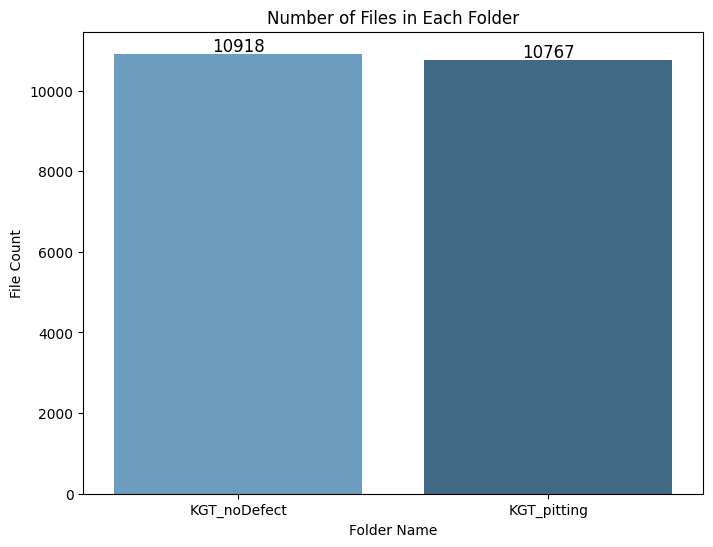

21685


In [4]:
df = pd.DataFrame({
    'Folder': ['KGT_noDefect', 'KGT_pitting'],
    'File Count': [len(no_defect), len(pitting)]
})

plt.figure(figsize=(8, 6))
barplot = sns.barplot(x='Folder', y='File Count', data=df, palette='Blues_d')

plt.title('Number of Files in Each Folder')
plt.xlabel('Folder Name')
plt.ylabel('File Count')

for p in barplot.patches:
    barplot.annotate(f'{int(p.get_height())}', 
                      (p.get_x() + p.get_width() / 2., p.get_height()), 
                      ha='center', va='center', 
                      fontsize=12, color='black', 
                      xytext=(0, 5), textcoords='offset points')

plt.show()

sum = len(no_defect) + len(pitting)
print(sum)

In [5]:
img_path = os.path.join(data_path, "KGT_noDefect", no_defect[0])

img = Image.open(img_path)

img.mode

'RGB'

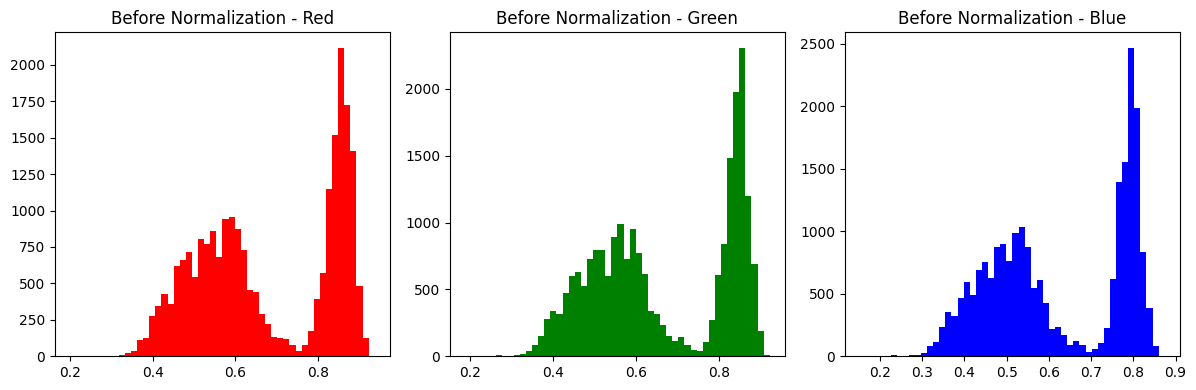

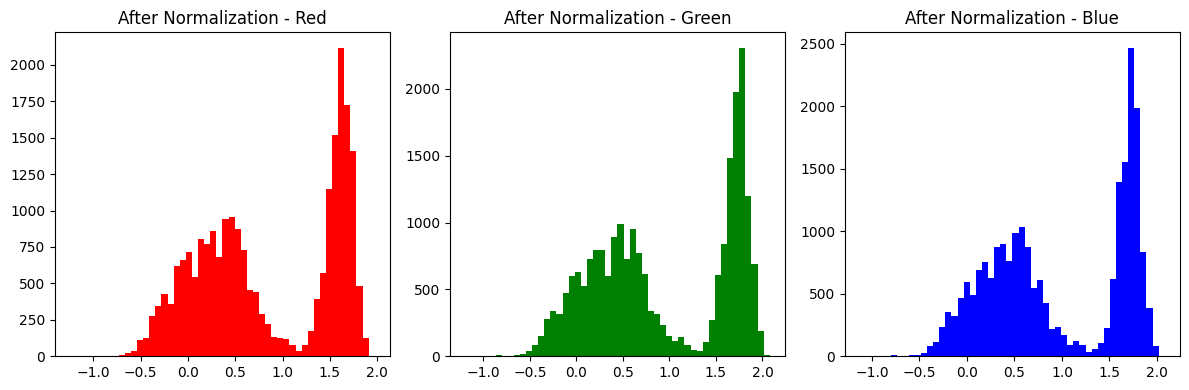

In [6]:
# Define transforms
to_tensor = transforms.ToTensor()
normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406], #values used in pretraining 
    std=[0.229, 0.224, 0.225]
)

# Apply transformations
tensor_img = to_tensor(img)
normalized_img = normalize(tensor_img)

# Plot histograms
def plot_histogram(tensor, title):
    plt.figure(figsize=(12, 4))
    channels = ['Red', 'Green', 'Blue']
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.hist(tensor[i].flatten().numpy(), bins=50, color=channels[i].lower())
        plt.title(f'{title} - {channels[i]}')
    plt.tight_layout()
    plt.show()

plot_histogram(tensor_img, "Before Normalization")
plot_histogram(normalized_img, "After Normalization")

In [7]:
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(           # Simulate lighting changes
        brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05
    ),
    transforms.RandomRotation(10),   # Optional small rotation
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],   # ImageNet mean/std
        std=[0.229, 0.224, 0.225]
    )
])

In [10]:
# Load dataset
dataset = datasets.ImageFolder(root=os.path.join(BASE, "dataset"), transform=transform)

# Sizes
total_size = len(dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size  # Ensures full coverage

# Split dataset
generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size], generator=generator)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [11]:
model = models.resnet18(pretrained=True)

# Modify the final layer for binary classification
model.fc = nn.Linear(model.fc.in_features, 2)

/Users/janikwahrheit/anaconda3/envs/pitting_env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/janikwahrheit/anaconda3/envs/pitting_env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [15]:
# Training loop with validation
num_epochs = 10
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    train_losses.append(running_train_loss)

    # Validation loop
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

    val_losses.append(running_val_loss)

    print(f"Epoch {epoch+1} | Train Loss: {running_train_loss:.4f} | Val Loss: {running_val_loss:.4f}")



Epoch 1 | Train Loss: 250.4239 | Val Loss: 34.9690
Epoch 2 | Train Loss: 176.2755 | Val Loss: 29.8364
Epoch 3 | Train Loss: 158.6697 | Val Loss: 25.8646
Epoch 4 | Train Loss: 144.7497 | Val Loss: 26.4516
Epoch 5 | Train Loss: 130.1671 | Val Loss: 24.4958
Epoch 6 | Train Loss: 125.7834 | Val Loss: 24.4624
Epoch 7 | Train Loss: 124.3033 | Val Loss: 21.4765
Epoch 8 | Train Loss: 114.4608 | Val Loss: 23.7805
Epoch 9 | Train Loss: 111.8790 | Val Loss: 24.0175
Epoch 10 | Train Loss: 108.6581 | Val Loss: 22.2442


In [17]:
# Save model
torch.save(model.state_dict(), os.path.join(BASE, "models",  "resnet18_pitting_not_simplified.pth"))

In [ ]:
# Final evaluation on the test set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("Test Accuracy:", accuracy_score(all_labels, all_preds))
print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

Test Accuracy: 0.9560540872771973
Confusion Matrix:
[[1594   78]
 [  65 1517]]


<Axes: >

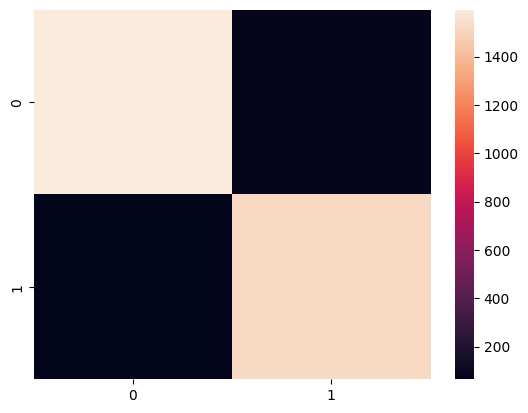

In [22]:
sns.heatmap(confusion_matrix(all_labels, all_preds)) 